In [1]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 19.1 MB/s eta 0:00:00


In [17]:
import numpy as np
theta_vals = np.linspace(0, 2 * np.pi, 10)
phi_vals = np.linspace(0, 2*np.pi, 10)
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

matrix = np.zeros((len(theta_vals), len(phi_vals)))

simulator = AerSimulator()

for i, theta in enumerate(theta_vals):
    for j, phi in enumerate(phi_vals):

        qc = QuantumCircuit(1, 1)
        qc.ry(theta, 0)
        qc.rz(phi, 0)
        qc.h(0)
        qc.measure(0, 0)

        job = simulator.run(qc, shots=1024)
        result = job.result()
        counts = result.get_counts()

        prob_0 = counts.get('0', 0) / 1024
        matrix[i][j] = prob_0


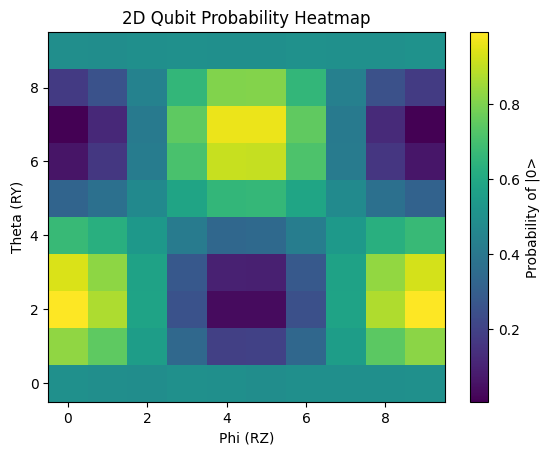

In [18]:
import matplotlib.pyplot as plt

plt.imshow(matrix, origin='lower', aspect='auto')
plt.colorbar(label='Probability of |0>')
plt.xlabel('Phi (RZ)')
plt.ylabel('Theta (RY)')
plt.title('2D Qubit Probability Heatmap')

plt.show()

